In [1]:
import numpy as np, tensorflow as tf, matplotlib.pyplot as plt, pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [6]:
rng = np.random.RandomState(42)
n = 700
X = pd.DataFrame({
  "EngineSize": rng.normal(1.8, 0.5, n).clip(0.8, 3.5),
  "HorsePower": rng.normal(110, 40, n).clip(50, 300),
  "Weight": rng.normal(1300, 300, n).clip(800, 2500),
  "Age": rng.randint(0, 15, n)
})
noise = rng.normal(0, 1.5, n)
y = 35 - 2.0*X["EngineSize"] - 0.015*X["HorsePower"] - 0.002*X["Weight"] - 0.1*X["Age"] + noise

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_tr = scaler.fit_transform(X_train)
X_test_tr = scaler.transform(X_test)
print(X_train)
print(X_train_tr)

     EngineSize  HorsePower       Weight  Age
82     2.538947  125.207914  1818.089155    6
51     1.607459   55.932616  1810.664483    3
220    2.957329  152.945270  1333.981123   11
669    2.345753   74.607891  1577.864621    8
545    1.401552   61.042389  1189.116899    5
..          ...         ...          ...  ...
71     2.569018   87.501329  1117.065129   10
106    2.743093  118.885351  1508.916234    8
270    2.520637  115.124177  1228.320370    7
435    1.837047  148.563487  1408.451058    2
102    1.628643  113.844831  1054.540335   10

[560 rows x 4 columns]
[[ 1.58394295  0.2882121   1.75386569 -0.16882186]
 [-0.40180976 -1.53121003  1.72775383 -0.87965076]
 [ 2.47585306  1.01669628  0.05130387  1.01589297]
 ...
 [ 1.54490876  0.02337635 -0.32029493  0.0681211 ]
 [ 0.08762861  0.90161466  0.31320753 -1.11659373]
 [-0.35664982 -0.01022393 -0.93146275  0.77895   ]]


In [9]:
tf.random.set_seed(42)
model = tf.keras.Sequential([
  tf.keras.layers.Input(shape=(X_train_tr.shape[1],)),
  tf.keras.layers.Dense(128, activation="relu"),
  tf.keras.layers.Dense(64, activation="relu"),
  tf.keras.layers.Dense(32, activation="relu"),
  tf.keras.layers.Dense(1)
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss="mse",
              metrics=["mae"]
              )

In [10]:
history = model.fit(X_train_tr, y_train, epochs=120, validation_data=(X_test_tr, y_test), verbose=0)

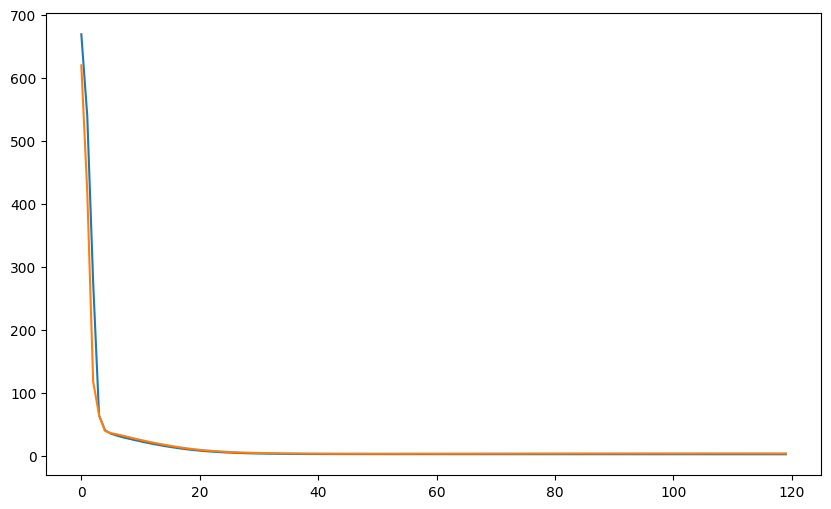

In [11]:
loss = history.history["loss"]
val_loss = history.history["val_loss"]

plt.figure(figsize=(10,6))
plt.plot(loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")


In [12]:
y_pred=model.predict(X_test_tr)
print(y_test.values)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
[28.87527713 25.42764412 27.56334467 26.02178466 28.86566712 26.4963122
 25.85045804 24.66637647 26.94481863 26.724308   27.09111185 25.48584285
 33.50277881 24.32003188 29.55987583 23.0502388  27.87541425 27.12339019
 27.05477204 28.31702088 24.9505846  25.29888128 23.96680625 28.05121659
 23.56436388 30.5437827  23.39303793 21.11943763 26.58321237 28.27882069
 26.46958687 25.09173242 28.08689394 26.49438789 28.61042504 25.20412219
 26.71220695 24.80408792 28.06086409 27.90167515 27.63190183 25.98086083
 25.53256619 28.66770341 24.30809566 26.80693944 26.00008071 23.29853944
 25.46053539 28.00941751 27.46119185 31.21700303 26.56161745 26.87578159
 27.950931   26.07068588 29.05229105 25.0605323  25.92726477 29.07649625
 28.28100284 26.72458791 25.14779336 28.03474608 26.58538684 27.05873589
 25.57205662 25.71296283 23.5620969  29.23135881 25.8672681  26.19575057
 27.41077777 29.52249232 21.75022716 26.39445351 26.41329134 25.81398524
 22.75748399 2

In [13]:
print(y_test.shape)
print(y_pred.shape)

(140,)
(140, 1)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


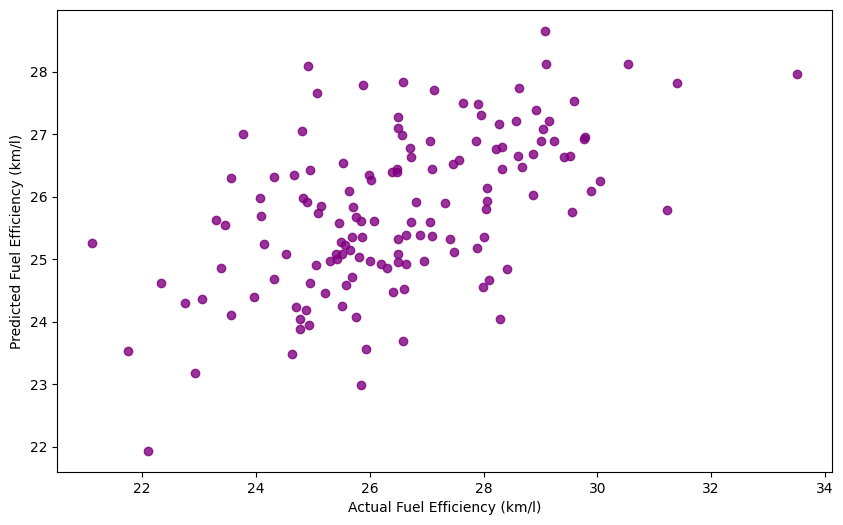

In [14]:
y_pred = model.predict(X_test_tr).flatten()

plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.8, color="purple")
plt.xlabel("Actual Fuel Efficiency (km/l)")
plt.ylabel("Predicted Fuel Efficiency (km/l)")
plt.show()